## Read the Trained Weight and Run FP32 Inference

In [1]:
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
from matplotlib import pyplot
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [2]:
###########################################################################
# Re-define the model architecture (must match the saved model)
###########################################################################

# CNN class
class CNN(nn.Module):
     # Initialization
    def __init__(self):
        super (CNN, self).__init__()
        
        self.conv1_out_np = np.zeros((1, 3, 24, 24))
        self.mp1_out_np = np.zeros((1, 3, 12, 12))
        self.conv2_out_np = np.zeros((1, 3, 8, 8))
        self.mp2_out_np = np.zeros((1, 3, 4, 4))
        self.fc_in_np = np.zeros((1, 48))
        self.fc_out_np = np.zeros((1, 10))
        
        # 1st Convolution Layer
        # Image Input Shape -> (28, 28, 1)
        # Convolution Layer -> (24, 24, 3)
        # Pooling Max Layer -> (12, 12, 3)
        self.conv1 = nn.Conv2d(1, 3, kernel_size=5)
        
        # 2nd Convolution Layer
        # Image Input Shape -> (12, 12, 3)
        # Convolution Layer -> (8, 8, 3)
        # pooling Max Layer -> (4, 4, 3)
        self.conv2 = nn.Conv2d(3, 3, kernel_size=5)
        
        # Max Pooling Layer
        self.mp = nn.MaxPool2d(2)
        
        # Fully Connected Layer
        # Num of Weight = 480
        self.fc_1 = nn.Linear(48, 10)
        
    def forward(self, x):
        in_size = x.size(0)
        
        # Layer Integration
        x = self.conv1(x)
        self.conv1_out_np = x.detach().numpy()
        
        x = F.relu(self.mp(x))
        self.mp1_out_np = x.detach().numpy()

        x = self.conv2(x)
        self.conv2_out_np = x.detach().numpy()
        
        x = F.relu(self.mp(x))
        self.mp2_out_np = x.detach().numpy()
        
        # Flatten Layer
        x = x.view(in_size, -1)
        self.fc_in_np = x.detach().numpy()
        
        # Fully Connected Layer
        x = self.fc_1(x)
        self.fc_out_np = x.detach().numpy()
        
        return F.log_softmax(x)

In [3]:
###########################################################################
# Load trained weights from .pt File
###########################################################################

# Load model
model = torch.load("./mnist_weights.pt", weights_only=False)
model.eval()
print(model)

CNN(
  (conv1): Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_1): Linear(in_features=48, out_features=10, bias=True)
)


Predicted output: 5


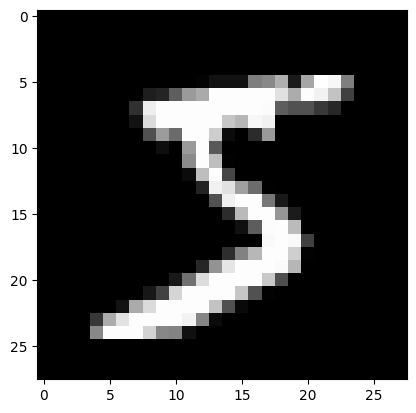

In [4]:
###########################################################################
# Perform inference using the original FP32 model
###########################################################################

# Load bitmap image
img = Image.open("./bmp/train_0.bmp", "r")
np_img = np.array(img)
pyplot.imshow(np_img, cmap=pyplot.get_cmap('gray'))

np_img_re = np.reshape(np_img, (1,1,28,28))
# 0 - 255 => 0 - 1 로 정규화, np.array => tensor 변환
data = Variable(torch.tensor((np_img_re / 255), dtype = torch.float32))
    
# Output of feedforwarding
output = model(data)
pred = output.data.max(1, keepdim=True)[1]
print('Predicted output: ' + ', '.join(map(str, pred.flatten().tolist())))

## Quantization and Run INT8 Inference

In [5]:
from torch.utils.data import DataLoader, TensorDataset
import copy
import glob

In [6]:
###########################################################################
# Naive matrix multiplication
###########################################################################

def manual_mmult(A, B):
    # Ensure inputs are 2D
    A_2d = A if A.ndim == 2 else A.reshape(-1, A.shape[-1])
    B_2d = B if B.ndim == 2 else B.reshape(-1, B.shape[-1])

    rows_A, cols_A = A_2d.shape
    rows_B, cols_B = B_2d.shape

    if cols_A != rows_B:
        raise ValueError(
            f"Incompatible shapes for matmul: {cols_A} != {rows_B}"
        )

    # Initialize 2D output array (using int32 for FPGA accumulation)
    result_2d = np.zeros((rows_A, cols_B), dtype=np.int32)

    # Standard matrix multiplication loops: (M x K) @ (K x N) -> (M x N)
    for i in range(rows_A):
        for j in range(cols_B):
            acc = 0
            for k in range(cols_A):
                acc += int(A_2d[i, k]) * int(B_2d[k, j])
            result_2d[i, j] = acc

    return result_2d

In [7]:
###########################################################################
# Function to get quantization scales
###########################################################################

def get_cnn_quantization_scales(model, calibration_loader):
    model.eval()

    # Track activation ranges entering each Conv2d and Linear layer
    max_input_conv1 = 0.0
    max_input_conv2 = 0.0
    max_input_fc1 = 0.0

    with torch.no_grad():
        for batch in calibration_loader:

            # Unpack input tensor from DataLoader
            x = batch[0] if isinstance(batch, (list, tuple)) else batch

            # ---------------------------------------------------------
            # Input to Conv 1 (conv1)
            # ---------------------------------------------------------
            max_input_conv1 = max(
                max_input_conv1,
                torch.max(torch.abs(x)).item()
            )

            # Pass through Conv 1, MaxPool, and ReLU
            conv1_out = model.conv1(x)
            mp1_out = F.relu(model.mp(conv1_out))

            # ---------------------------------------------------------
            # Input to Conv 2 (conv2)
            # ---------------------------------------------------------
            max_input_conv2 = max(
                max_input_conv2,
                torch.max(torch.abs(mp1_out)).item()
            )

            # Pass through Conv 2, MaxPool, ReLU, and Flatten
            conv2_out = model.conv2(mp1_out)
            mp2_out = F.relu(model.mp(conv2_out))
            flatten_out = mp2_out.view(x.size(0), -1)

            # ---------------------------------------------------------
            # Input to Linear 1 (fc_1)
            # ---------------------------------------------------------
            max_input_fc1 = max(
                max_input_fc1,
                torch.max(torch.abs(flatten_out)).item()
            )

    # ---------------------------------------------------------
    # Activation quantization scales (symmetric int8)
    # ---------------------------------------------------------
    conv1_input_scale = max_input_conv1 / 127.0
    conv2_input_scale = max_input_conv2 / 127.0
    fc1_input_scale = max_input_fc1 / 127.0

    # ---------------------------------------------------------
    # Weight quantization scales (symmetric int8)
    # ---------------------------------------------------------
    conv1_weight_scale = torch.max(torch.abs(model.conv1.weight)).item() / 127.0
    conv2_weight_scale = torch.max(torch.abs(model.conv2.weight)).item() / 127.0
    fc1_weight_scale = torch.max(torch.abs(model.fc_1.weight)).item() / 127.0

    return {
        "conv1_input_scale": conv1_input_scale,
        "conv1_weight_scale": conv1_weight_scale,
        "conv2_input_scale": conv2_input_scale,
        "conv2_weight_scale": conv2_weight_scale,
        "fc1_input_scale": fc1_input_scale,
        "fc1_weight_scale": fc1_weight_scale,
    }

In [8]:
###########################################################################
# Get quantization scale
###########################################################################

# Load and preprocess all bitmap calibration images
img_list = []
for file_path in glob.glob("./bmp/*.bmp"):
    img = Image.open(file_path, "r")
    np_img = np.array(img)
    img_list.append(np_img)

# Stack into shape: (N, 1, 28, 28) and normalize
X_np = np.array(img_list)
X_np = np.reshape(X_np, (-1, 1, 28, 28))
X_tensor = torch.tensor(X_np / 255.0, dtype=torch.float32)

# Construct TensorDataset and DataLoader
calibration_dataset = TensorDataset(X_tensor)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=2,  # Set desired batch size
    shuffle=False
)

# Calculate INT8 scales
scales = get_cnn_quantization_scales(model, calibration_loader)
print(scales)

{'conv1_input_scale': 0.007874015748031496, 'conv1_weight_scale': 0.006037354469299316, 'conv2_input_scale': 0.05826826921598179, 'conv2_weight_scale': 0.005264025973522757, 'fc1_input_scale': 0.12223809159646823, 'fc1_weight_scale': 0.005310128523608831}


In [9]:
###########################################################################
# Quantized INT8 conv2d class
###########################################################################

class QuantizedConv2d(nn.Module):

    def __init__(self, original_layer, input_scale, weight_scale):
        super().__init__()

        self.in_channels = original_layer.in_channels
        self.out_channels = original_layer.out_channels
        self.kernel_size = original_layer.kernel_size
        self.stride = original_layer.stride
        self.padding = original_layer.padding
        self.dilation = original_layer.dilation

        # Quantization scales
        self.input_scale = input_scale
        self.weight_scale = weight_scale

        # ---------------------------------------------------------------
        # Quantize weights using the calibrated weight scale
        # Original weight shape: (out_channels, in_channels, K_H, K_W)
        # Reshaped weight matrix (W): (out_channels, in_channels * K_H * K_W)
        # ---------------------------------------------------------------
        weights_float = original_layer.weight.detach().cpu().numpy()
        weights_flattened = weights_float.reshape(self.out_channels, -1)

        self.weights_int8 = np.round(
            weights_flattened / self.weight_scale
        ).clip(-128, 127).astype(np.int8)

        # Keep bias in floating point for simplicity
        if original_layer.bias is not None:
            self.bias = original_layer.bias.detach().clone().cpu().numpy()
        else:
            self.bias = None

    def forward(self, x):
        batch_size = x.size(0)
        in_h, in_w = x.size(2), x.size(3)

        # 1. FP32 -> INT8 Activation Quantization
        x_np = x.detach().cpu().numpy()
        x_int8 = np.round(
            x_np / self.input_scale
        ).clip(-128, 127).astype(np.int8)

        # Re-wrap as torch tensor to perform im2col unrolling via F.unfold
        x_int8_tensor = torch.from_numpy(x_int8).to(torch.float32)
        
        # Unroll spatial image patches into columns (im2col)
        # Output shape: (batch_size, in_channels * K_H * K_W, L)
        # where L = output_height * output_width
        x_unfolded = F.unfold(
            x_int8_tensor,
            kernel_size=self.kernel_size,
            dilation=self.dilation,
            padding=self.padding,
            stride=self.stride
        ).numpy().astype(np.int8)

        # Calculate spatial output dimensions
        k_h = self.kernel_size[0] if isinstance(self.kernel_size, tuple) else self.kernel_size
        k_w = self.kernel_size[1] if isinstance(self.kernel_size, tuple) else self.kernel_size
        p_h = self.padding[0] if isinstance(self.padding, tuple) else self.padding
        p_w = self.padding[1] if isinstance(self.padding, tuple) else self.padding
        s_h = self.stride[0] if isinstance(self.stride, tuple) else self.stride
        s_w = self.stride[1] if isinstance(self.stride, tuple) else self.stride

        out_h = int((in_h + 2 * p_h - k_h) / s_h + 1)
        out_w = int((in_w + 2 * p_w - k_w) / s_w + 1)

        outputs = []
        
        # Process each image in the batch
        for b in range(batch_size):
            # Transpose unfolded patch matrix for matmul: (L, in_channels * K_H * K_W)
            patch_matrix = x_unfolded[b].T  
            
            x1_shape = patch_matrix.shape
            x2_shape = self.weights_int8.T.shape
            print(f"DEBUG: matmul X1{x1_shape} * X2{x2_shape}")

            # 2. INT8 x INT8 -> INT32 Matrix Multiplication
            # (L, K_dim) * (K_dim, out_channels) -> (L, out_channels)
            out_int32 = manual_mmult(
                patch_matrix.astype(np.int32),
                self.weights_int8.T.astype(np.int32)
            )

            # 3. INT32 -> FP32 Dequantization
            total_scale = self.input_scale * self.weight_scale
            out_float = out_int32.astype(np.float32) * total_scale

            # Add FP32 bias if present
            if self.bias is not None:
                out_float += self.bias  # Broadcast across channels

            # Reshape back from (L, out_channels) -> (out_channels, out_h, out_w)
            out_float = out_float.T.reshape(self.out_channels, out_h, out_w)
            outputs.append(out_float)

        # Stack batch dimension: (batch_size, out_channels, out_h, out_w)
        final_out = np.stack(outputs, axis=0)

        return torch.from_numpy(final_out).to(x.device).contiguous()

In [10]:
###########################################################################
# Quantized INT8 linear class
###########################################################################

class QuantizedLinear(nn.Module):

    def __init__(self, original_layer, input_scale, weight_scale):
        super().__init__()

        self.in_features = original_layer.in_features
        self.out_features = original_layer.out_features

        # Quantization scales
        self.input_scale = input_scale
        self.weight_scale = weight_scale

        # ---------------------------------------------------------------
        # Quantize weights using the calibrated weight scale
        # ---------------------------------------------------------------
        weights_float = original_layer.weight.detach().cpu().numpy()

        self.weights_int8 = np.round(
            weights_float / self.weight_scale
        ).clip(-128, 127).astype(np.int8)

        # Keep bias in floating point for simplicity
        if original_layer.bias is not None:
            self.bias = original_layer.bias.detach().clone()
        else:
            self.bias = None

    def forward(self, x):

        # FP32 -> INT8
        x_np = x.detach().cpu().numpy()

        x_int8 = np.round(
            x_np / self.input_scale
        ).clip(-128, 127).astype(np.int8)

        # INT8 x INT8 -> INT32
        x1_shape = x_int8.shape
        x2_shape = self.weights_int8.T.shape
        print(f"DEBUG: matmul X1{x1_shape} * X2{x2_shape}")

        out_int32 = manual_mmult(
            x_int8.astype(np.int32),
            self.weights_int8.T.astype(np.int32)
        )

        # INT32 -> FP32
        total_scale = self.input_scale * self.weight_scale

        out_float = (
            out_int32.astype(np.float32) * total_scale
        )

        # Add FP32 bias
        if self.bias is not None:
            out_float += self.bias.cpu().numpy()

        return torch.from_numpy(out_float).to(x.device)

In [11]:
###########################################################################
# Function to integrate quantized linear class
###########################################################################

def integrate_quantization_layer(model, scales):
    """
    Recursively replaces all nn.Conv2d layers with QuantizedConv2d
    and nn.Linear layers with QuantizedLinear.

    Each layer uses its corresponding calibrated input and weight quantization scales.
    """

    for name, module in model.named_children():

        if isinstance(module, nn.Conv2d):
            # ---------------------------------------------------------
            # Select quantization scales for Conv2d layers
            # ---------------------------------------------------------
            if name == "conv1":
                input_scale = scales["conv1_input_scale"]
                weight_scale = scales["conv1_weight_scale"]

            elif name == "conv2":
                input_scale = scales["conv2_input_scale"]
                weight_scale = scales["conv2_weight_scale"]

            else:
                raise ValueError(
                    f"No quantization scale found for Conv2d layer: {name}"
                )

            # ---------------------------------------------------------
            # Create quantized Conv2d layer
            # ---------------------------------------------------------
            quantized_layer = QuantizedConv2d(
                module,
                input_scale,
                weight_scale
            )

            # Replace FP32 Conv2d with QuantizedConv2d
            setattr(model, name, quantized_layer)

            print(
                f"Replaced layer: {name} "
                f"with QuantizedConv2d "
                f"(input_scale={input_scale:.6f}, "
                f"weight_scale={weight_scale:.6f})"
            )

        elif isinstance(module, nn.Linear):
            # ---------------------------------------------------------
            # Select quantization scales for Linear layers
            # ---------------------------------------------------------
            if name == "fc_1":
                input_scale = scales["fc1_input_scale"]
                weight_scale = scales["fc1_weight_scale"]

            else:
                raise ValueError(
                    f"No quantization scale found for Linear layer: {name}"
                )

            # ---------------------------------------------------------
            # Create quantized Linear layer
            # ---------------------------------------------------------
            quantized_layer = QuantizedLinear(
                module,
                input_scale,
                weight_scale
            )

            # Replace FP32 Linear with QuantizedLinear
            setattr(model, name, quantized_layer)

            print(
                f"Replaced layer: {name} "
                f"with QuantizedLinear "
                f"(input_scale={input_scale:.6f}, "
                f"weight_scale={weight_scale:.6f})"
            )

        else:
            # Recursively process child modules
            integrate_quantization_layer(module, scales)

In [12]:
###########################################################################
# Replace the FP32 conv2d & linear classes with INT8 Quantized classes
###########################################################################

# Create an isolated deep copy for quantization
# The original FP32 model remains unchanged.
model_quantized = copy.deepcopy(model)

print("\n--- Before Quantization ---")
print("Original model:")
print("  Conv 1:", model.conv1)
print("  Conv 2:", model.conv2)
print("  FC 1:  ", model.fc_1)

print("\nQuantized model copy:")
print("  Conv 1:", model_quantized.conv1)
print("  Conv 2:", model_quantized.conv2)
print("  FC 1:  ", model_quantized.fc_1)
print("")

# Apply quantization ONLY to the copied model
integrate_quantization_layer(model_quantized, scales)

print("\n--- After Quantization ---")
print("Original model (unchanged):")
print("  Conv 1:", model.conv1)
print("  Conv 2:", model.conv2)
print("  FC 1:  ", model.fc_1)

print("\nQuantized model:")
print("  Conv 1:", model_quantized.conv1)
print("  Conv 2:", model_quantized.conv2)
print("  FC 1:  ", model_quantized.fc_1)


--- Before Quantization ---
Original model:
  Conv 1: Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  Conv 2: Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  FC 1:   Linear(in_features=48, out_features=10, bias=True)

Quantized model copy:
  Conv 1: Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  Conv 2: Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  FC 1:   Linear(in_features=48, out_features=10, bias=True)

Replaced layer: conv1 with QuantizedConv2d (input_scale=0.007874, weight_scale=0.006037)
Replaced layer: conv2 with QuantizedConv2d (input_scale=0.058268, weight_scale=0.005264)
Replaced layer: fc_1 with QuantizedLinear (input_scale=0.122238, weight_scale=0.005310)

--- After Quantization ---
Original model (unchanged):
  Conv 1: Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  Conv 2: Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  FC 1:   Linear(in_features=48, out_features=10, bias=True)

Quantized model:
  Conv 1: QuantizedConv2d()
  Conv 2: QuantizedConv2d()
  FC

DEBUG: matmul X1(576, 25) * X2(25, 3)
DEBUG: matmul X1(64, 75) * X2(75, 3)
DEBUG: matmul X1(1, 48) * X2(48, 10)
Predicted output: 5


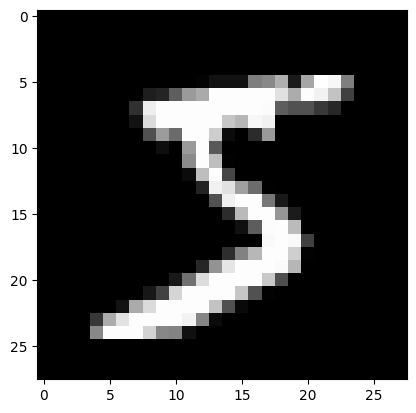

In [13]:
###########################################################################
# Perform inference using the INT8 quantized model
###########################################################################

# Load bitmap image
img = Image.open("./bmp/train_0.bmp", "r")
np_img = np.array(img)
pyplot.imshow(np_img, cmap=pyplot.get_cmap('gray'))

np_img_re = np.reshape(np_img, (1,1,28,28))
# 0 - 255 => 0 - 1 로 정규화, np.array => tensor 변환
data = Variable(torch.tensor((np_img_re / 255), dtype = torch.float32))
    
# Output of feedforwarding
output = model_quantized(data)
pred = output.data.max(1, keepdim=True)[1]
print('Predicted output: ' + ', '.join(map(str, pred.flatten().tolist())))

DEBUG: matmul X1(576, 25) * X2(25, 3)
DEBUG: matmul X1(64, 75) * X2(75, 3)
DEBUG: matmul X1(1, 48) * X2(48, 10)

--- FP32 vs INT8 Model Comparison ---
Sample / Class         |  FP32 Prob |  INT8 Prob |  Abs Error |  FP32 Pred |  INT8 Pred
------------------------------------------------------------------------------------------
Digit Class 0          |     0.0000 |     0.0000 |     0.0000 |            |           
Digit Class 1          |     0.0000 |     0.0000 |     0.0000 |            |           
Digit Class 2          |     0.0000 |     0.0000 |     0.0000 |            |           
Digit Class 3          |     0.0000 |     0.0000 |     0.0000 |            |           
Digit Class 4          |     0.0391 |     0.0419 |     0.0028 |            |           
Digit Class 5          |     0.0000 |     0.0000 |     0.0000 |            |           
Digit Class 6          |     0.0000 |     0.0000 |     0.0000 |            |           
Digit Class 7          |     0.0001 |     0.0001 |    

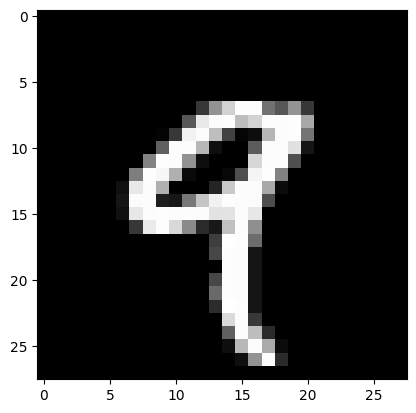

In [14]:
###########################################################################
# Quantization error calculation
###########################################################################

# Load bitmap image
img = Image.open("./bmp/train_4.bmp", "r")
np_img = np.array(img)
pyplot.imshow(np_img, cmap=pyplot.get_cmap('gray'))

np_img_re = np.reshape(np_img, (1,1,28,28))
# 0 - 255 => 0 - 1 로 정규화, np.array => tensor 변환
data = Variable(torch.tensor((np_img_re / 255), dtype = torch.float32))

# Set both models to evaluation mode
model.eval()
model_quantized.eval()

with torch.no_grad():
    # 1. Forward pass through original FP32 model
    raw_log_softmax_fp32 = model(data)
    probabilities_fp32 = torch.exp(raw_log_softmax_fp32)  # Convert log-softmax -> probabilities
    predictions_fp32 = torch.argmax(probabilities_fp32, dim=1)

    # 2. Forward pass through INT8 Quantized model
    raw_log_softmax_int8 = model_quantized(data)
    probabilities_int8 = torch.exp(raw_log_softmax_int8)
    predictions_int8 = torch.argmax(probabilities_int8, dim=1)

# Calculate absolute element-wise probability errors across all classes
errors = torch.abs(probabilities_fp32 - probabilities_int8)

print("\n--- FP32 vs INT8 Model Comparison ---")
print(
    f"{'Sample / Class':22s} | "
    f"{'FP32 Prob':>10s} | "
    f"{'INT8 Prob':>10s} | "
    f"{'Abs Error':>10s} | "
    f"{'FP32 Pred':>10s} | "
    f"{'INT8 Pred':>10s}"
)
print("-" * 90)

# If evaluating a single image (batch size 1), loop through all 10 digit classes
batch_size = data.size(0)

if batch_size == 1:
    # Compare output probability for each class digit (0 to 9)
    p_fp32_sample = probabilities_fp32[0]
    p_int8_sample = probabilities_int8[0]
    err_sample = errors[0]

    pred_digit_fp32 = predictions_fp32[0].item()
    pred_digit_int8 = predictions_int8[0].item()

    for class_idx in range(10):
        class_label = f"Digit Class {class_idx}"
        p_fp32 = p_fp32_sample[class_idx].item()
        p_int8 = p_int8_sample[class_idx].item()
        err = err_sample[class_idx].item()

        # Show prediction tag if this class is the winning prediction
        is_pred_fp32 = f"Digit {pred_digit_fp32}" if class_idx == pred_digit_fp32 else ""
        is_pred_int8 = f"Digit {pred_digit_int8}" if class_idx == pred_digit_int8 else ""

        print(
            f"{class_label:22s} | "
            f"{p_fp32:10.4f} | "
            f"{p_int8:10.4f} | "
            f"{err:10.4f} | "
            f"{is_pred_fp32:>10s} | "
            f"{is_pred_int8:>10s}"
        )
else:
    # If evaluating a batch of images, loop through each image in the batch
    for i in range(batch_size):
        image_name = f"Image #{i}"
        
        # Selected class probability (confidence score for top predicted class)
        pred_idx_fp32 = predictions_fp32[i].item()
        pred_idx_int8 = predictions_int8[i].item()

        p_fp32 = probabilities_fp32[i, pred_idx_fp32].item()
        p_int8 = probabilities_int8[i, pred_idx_int8].item()
        err = torch.max(errors[i]).item()

        print(
            f"{image_name:22s} | "
            f"{p_fp32:10.4f} | "
            f"{p_int8:10.4f} | "
            f"{err:10.4f} | "
            f"{f'Digit {pred_idx_fp32}':>10s} | "
            f"{f'Digit {pred_idx_int8}':>10s}"
        )

print("-" * 90)
print(f"Mean Absolute Probability Error:    {errors.mean().item():.6f}")
print(f"Maximum Absolute Probability Error: {errors.max().item():.6f}")